# Performance Analysis

This notebook compares:
- numerical, analytical, and BruFit timing;
- analytical and numerical MINUIT outcomes for the million-start runs;
- best-fit values from analytical and numerical gradients;
- best-fit values from EMI and BruFit.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import ROOT

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "text.usetex": True,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.8,
    "savefig.dpi": 300,
})


OUT_DIR = Path("outputs/performance_analysis")
OUT_DIR.mkdir(exist_ok=True, parents=True)

BRUFIT = Path("/home/dleahy27/Desktop/PhD/brufit/tutorials/ElectroAmps/TwoSpin0AmpsFromMoments")

# Timing: numerical EMI, analytical EMI, and BruFit

In [74]:
def lin_model(x,m):
    return m*x

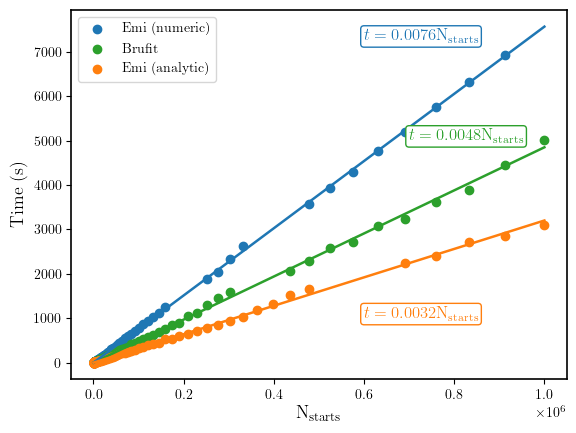

In [75]:
startsn, tn = np.loadtxt("../numeric_times.csv", delimiter=",", unpack=True, skiprows=1)
startsa, ta = np.loadtxt("../analytic_times.csv", delimiter=",", unpack=True, skiprows=1)
startsb, tb = np.loadtxt(BRUFIT / "brufit_times.csv", delimiter=",", unpack=True, skiprows=1)

popt_n,_ = curve_fit(lin_model,startsn,tn, p0=(1))
popt_a,_ = curve_fit(lin_model,startsa,ta, p0=(1))
popt_b,_ = curve_fit(lin_model,startsb,tb, p0=1)

starts = np.logspace(1,6,1001)

n_model = lin_model(starts, *popt_n)
a_model = lin_model(starts, *popt_a)
b_model = lin_model(starts, *popt_b)

fig,ax = plt.subplots(1,1)

ax.scatter(startsn,tn,label="Emi (numeric)", c="tab:blue")
ax.scatter(startsb,tb,label="Brufit", c="tab:green")
ax.scatter(startsa,ta,label="Emi (analytic)", c="tab:orange")

ax.plot(starts,b_model, c="tab:green")
ax.plot(starts,n_model, c="tab:blue")
ax.plot(starts,a_model, c="tab:orange")

ax.text(6E5,1000,f"$t = {popt_a[0]:.4f}\\mathrm{{N}}_{{\\mathrm{{starts}}}}$ ", color="tab:orange",
        bbox ={'boxstyle':'round','ec':'tab:orange','fc':"white",'pad':0.2})
ax.text(6E5,7250,f"$t = {popt_n[0]:.4f}\\mathrm{{N}}_{{\\mathrm{{starts}}}}$ ", color="tab:blue",
        bbox ={'boxstyle':'round','ec':'tab:blue','fc':"white",'pad':0.2})
ax.text(7E5,5000,f"$t = {popt_b[0]:.4f}\\mathrm{{N}}_{{\\mathrm{{starts}}}}$ ", color="tab:green",
        bbox ={'boxstyle':'round','ec':'tab:green','fc':"white",'pad':0.2})


ax.set_xlabel(r"N$_{\mathrm{starts}}$")
ax.set_ylabel("Time (s)")
ax.legend()

fig.savefig(OUT_DIR / "numeric_v_analytic.png", dpi=300, bbox_inches="tight")


# Analytical vs numerical MINUIT outcomes

A good minimum has a finite `chi2`, `fit_ok == True`, and `status == 0`.
A good Hessian additionally has `hesse_ok == True` and `cov_status >= 2`.

These timing files were produced with `--no-hesse`, so zero good Hessians means HESSE was disabled rather than attempted and failed.

Analytical
  total starts: 1000000
  finite chi2: 1000000
  fit_ok: 525445
  good minima: 460762
  hesse_ok: 0
  good Hessians: 0
  status counts: {np.int32(0): np.int64(460762), np.int32(1): np.int64(64683), np.int32(2): np.int64(20181), np.int32(3): np.int64(454374)}
  covariance status counts: {np.int32(0): np.int64(20182), np.int32(1): np.int64(1034), np.int32(2): np.int64(509352), np.int32(3): np.int64(469432)}
Numerical
  total starts: 1000000
  finite chi2: 1000000
  fit_ok: 531380
  good minima: 487519
  hesse_ok: 0
  good Hessians: 0
  status counts: {np.int32(0): np.int64(487519), np.int32(1): np.int64(43861), np.int32(2): np.int64(14942), np.int32(3): np.int64(453678)}
  covariance status counts: {np.int32(0): np.int64(15619), np.int32(1): np.int64(12737), np.int32(2): np.int64(471380), np.int32(3): np.int64(500264)}


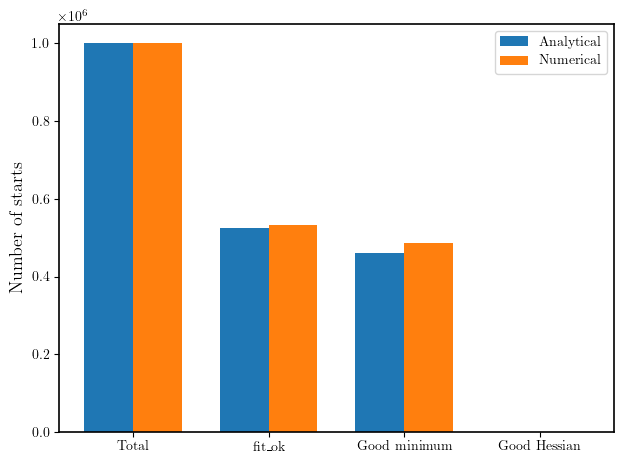

In [71]:
analytic_file = Path("../OutputFiles/gradient_analytic_0.root")
numeric_file = Path("../OutputFiles/gradient_numeric_0.root")

status_columns = ["fit_ok", "hesse_ok", "status", "cov_status", "chi2"]
analytic_status = ROOT.RDataFrame("fitResults", str(analytic_file)).AsNumpy(columns=status_columns)
numeric_status = ROOT.RDataFrame("fitResults", str(numeric_file)).AsNumpy(columns=status_columns)

labels = ["Analytical", "Numerical"]
status_data = [analytic_status, numeric_status]
summary = []

for label, data in zip(labels, status_data):
    finite = np.isfinite(data["chi2"])
    good_minimum = finite & data["fit_ok"] & (data["status"] == 0)
    good_hessian = good_minimum & data["hesse_ok"] & (data["cov_status"] >= 2)
    status_codes, status_counts = np.unique(data["status"], return_counts=True)
    cov_codes, cov_counts = np.unique(data["cov_status"], return_counts=True)

    summary.append([
        len(data["chi2"]),
        np.count_nonzero(finite),
        np.count_nonzero(data["fit_ok"]),
        np.count_nonzero(good_minimum),
        np.count_nonzero(data["hesse_ok"]),
        np.count_nonzero(good_hessian),
    ])

    print(label)
    print("  total starts:", len(data["chi2"]))
    print("  finite chi2:", np.count_nonzero(finite))
    print("  fit_ok:", np.count_nonzero(data["fit_ok"]))
    print("  good minima:", np.count_nonzero(good_minimum))
    print("  hesse_ok:", np.count_nonzero(data["hesse_ok"]))
    print("  good Hessians:", np.count_nonzero(good_hessian))
    print("  status counts:", dict(zip(status_codes, status_counts)))
    print("  covariance status counts:", dict(zip(cov_codes, cov_counts)))

summary = np.asarray(summary)

x = np.arange(4)
width = 0.36
fig, ax = plt.subplots()
ax.bar(x - width / 2, summary[0, [0, 2, 3, 5]], width, label="Analytical")
ax.bar(x + width / 2, summary[1, [0, 2, 3, 5]], width, label="Numerical")
ax.set_xticks(x, ["Total", "fit_ok", "Good minimum", "Good Hessian"])
ax.set_ylabel("Number of starts")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "analytic_v_numeric_status.png", bbox_inches="tight")

# Best analytical and numerical values

The comparison uses the lowest-`chi2` good minimum from each file. Phase differences are wrapped into $[-\pi, \pi]$.

In [72]:
analytic = ROOT.RDataFrame("fitResults", str(analytic_file))
numeric = ROOT.RDataFrame("fitResults", str(numeric_file))

analytic_good = analytic.Filter("fit_ok && status == 0 && std::isfinite(chi2)")
numeric_good = numeric.Filter("fit_ok && status == 0 && std::isfinite(chi2)")

analytic_min = analytic_good.Min("chi2").GetValue()
numeric_min = numeric_good.Min("chi2").GetValue()

analytic_columns = {str(name) for name in analytic.GetColumnNames()}
numeric_columns = {str(name) for name in numeric.GetColumnNames()}
amplitude_columns = sorted(
    name for name in analytic_columns & numeric_columns
    if name.startswith(("a_", "b_", "aphi_", "bphi_")) and not name.startswith("err__")
)

analytic_best = analytic_good.Filter(f"chi2 == {analytic_min:.17g}").Range(1).AsNumpy(
    columns=["chi2"] + amplitude_columns
)
numeric_best = numeric_good.Filter(f"chi2 == {numeric_min:.17g}").Range(1).AsNumpy(
    columns=["chi2"] + amplitude_columns
)

print(f"Analytical minimum chi2: {analytic_min:.12g}")
print(f"Numerical minimum chi2:  {numeric_min:.12g}")
print(f"Difference:              {numeric_min - analytic_min:.6g}")
print()
print(f"{'branch':<20} {'analytical':>14} {'numerical':>14} {'difference':>14}")

for name in amplitude_columns:
    analytical_value = analytic_best[name][0]
    numerical_value = numeric_best[name][0]
    difference = numerical_value - analytical_value
    if name.startswith(("aphi_", "bphi_")):
        difference = np.arctan2(np.sin(difference), np.cos(difference))
    print(f"{name:<20} {analytical_value:14.7g} {numerical_value:14.7g} {difference:14.7g}")

Analytical minimum chi2: 2.56664622901
Numerical minimum chi2:  2.56664622901
Difference:              1.03162e-12

branch                   analytical      numerical     difference
a_L_1_0                     0.62999        0.62999   1.328051e-08
a_L_1_1                  0.02682166     0.02682166  -8.313633e-09
a_T_1_0                   0.1264118      0.1264118  -9.091806e-09
a_T_1_1                   0.7670374      0.7670374   7.226643e-09
a_T_1_m1                 0.04850008     0.04850007  -9.469466e-09
aphi_L_1_0               -0.3622369     -0.3622369  -3.077683e-08
aphi_L_1_1                 3.013874       3.013873  -8.895955e-07
aphi_T_1_0               -0.2919866     -0.2919867  -1.589466e-08
aphi_T_1_1                        0              0              0
aphi_T_1_m1                2.589546       2.589547   2.384115e-07
b_L_1_0                           0              0              0
b_L_1_1                  0.03225169     0.03225161  -7.466172e-08
b_T_1_0                  0

# EMI vs BruFit best values

The EMI row is its lowest-`chi2` good minimum. The BruFit row is its lowest finite `val`.

BruFit's `PartialWaves` tree does not persist MINUIT, HESSE, or covariance status codes, so only fitted values and the objective can be compared from the existing file.

In [73]:
emi_file = Path("../OutputFiles/e_rho_fit_0.root")
brufit_file = BRUFIT / "resultsGivenMoments_eRhoFirstBin.root"

emi = ROOT.RDataFrame("fitResults", str(emi_file))
brufit = ROOT.RDataFrame("PartialWaves", str(brufit_file))

emi_good = emi.Filter("fit_ok && status == 0 && std::isfinite(chi2)")
brufit_good = brufit.Filter("std::isfinite(val)")

emi_min = emi_good.Min("chi2").GetValue()
brufit_min = brufit_good.Min("val").GetValue()

emi_columns = {str(name) for name in emi.GetColumnNames()}
brufit_columns = {str(name) for name in brufit.GetColumnNames()}
common_amplitudes = sorted(
    name for name in emi_columns & brufit_columns
    if name.startswith(("a_", "b_", "aphi_", "bphi_")) and not name.startswith("err__")
)

emi_best = emi_good.Filter(f"chi2 == {emi_min:.17g}").Range(1).AsNumpy(
    columns=["chi2"] + common_amplitudes
)
brufit_best = brufit_good.Filter(f"val == {brufit_min:.17g}").Range(1).AsNumpy(
    columns=["val"] + common_amplitudes
)

print(f"EMI minimum chi2: {emi_min:.12g}")
print(f"BruFit minimum val: {brufit_min:.12g}")
print(f"Difference:         {brufit_min - emi_min:.6g}")
print()
print(f"{'branch':<20} {'EMI':>14} {'BruFit':>14} {'difference':>14}")

for name in common_amplitudes:
    emi_value = emi_best[name][0]
    brufit_value = brufit_best[name][0]
    difference = brufit_value - emi_value
    if name.startswith(("aphi_", "bphi_")):
        difference = np.arctan2(np.sin(difference), np.cos(difference))
    print(f"{name:<20} {emi_value:14.7g} {brufit_value:14.7g} {difference:14.7g}")

EMI minimum chi2: 2.56664622901
BruFit minimum val: 2.56664622915
Difference:         1.39388e-10

branch                          EMI         BruFit     difference
a_L_1_0                     0.62999      0.6299899  -1.098936e-07
a_L_1_1                  0.02682167     0.02682177   1.053994e-07
a_T_1_0                   0.1264118      0.1264119   1.104379e-07
a_T_1_1                   0.7670374      0.7670372  -1.959852e-07
a_T_1_m1                 0.04850008     0.04850022   1.441248e-07
aphi_L_1_0               -0.3622369     -0.3622371  -2.353474e-07
aphi_L_1_1                 3.013873        3.01387  -2.984294e-06
aphi_T_1_0               -0.2919866     -0.2919881  -1.459551e-06
aphi_T_1_m1                2.589546        2.58954  -6.774866e-06
b_L_1_1                  0.03225168     0.03225228   6.001326e-07
b_T_1_0                  0.07044957      0.0704496   3.265276e-08
b_T_1_1                   0.1760972      0.1760974   2.292766e-07
b_T_1_m1                  0.1924134      0.